In [34]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.DataFrame({'employee': ['Gary', 'Stu', 'Mary', 'Sue'],
                    'group': ['Accounting', 'Marketing', 'Marketing', 'HR']})
df1

,employee,group
0,Gary,Accounting
1,Stu,Marketing
2,Mary,Marketing
3,Sue,HR


In [3]:
df2 = pd.DataFrame({'employee': ['Mary', 'Stu', 'Gary', 'Sue'],
                    'hire_date': [2008, 2012, 2017, 2018]})
df2

,employee,hire_date
0,Mary,2008
1,Stu,2012
2,Gary,2017
3,Sue,2018


In [4]:
df_combined = pd.merge(df1, df2)
df_combined

,employee,group,hire_date
0,Gary,Accounting,2017
1,Stu,Marketing,2012
2,Mary,Marketing,2008
3,Sue,HR,2018


In [5]:
df3 = pd.DataFrame({'group': ['Accounting', 'Marketing', 'HR'],
                    'supervisor': ['Carlos', 'Giada', 'Stephanie']})
df3

,group,supervisor
0,Accounting,Carlos
1,Marketing,Giada
2,HR,Stephanie


In [6]:
pd.merge(df_combined, df3)

,employee,group,hire_date,supervisor
0,Gary,Accounting,2017,Carlos
1,Stu,Marketing,2012,Giada
2,Mary,Marketing,2008,Giada
3,Sue,HR,2018,Stephanie


In [7]:
pd.merge(df_combined, df3, on='group')

,employee,group,hire_date,supervisor
0,Gary,Accounting,2017,Carlos
1,Stu,Marketing,2012,Giada
2,Mary,Marketing,2008,Giada
3,Sue,HR,2018,Stephanie


In [8]:
df4 = pd.DataFrame({'group': ['Accounting', 'Accounting', 'Marketing', 'Marketing', 'HR', 'HR'],
                    'core_skills': ['math', 'spreadsheets', 'writing', 'communication',
                                    'spreadsheets', 'organization']})
df4

,group,core_skills
0,Accounting,math
1,Accounting,spreadsheets
2,Marketing,writing
3,Marketing,communication
4,HR,spreadsheets
5,HR,organization


In [9]:
pd.merge(df1, df4, on='group')

,employee,group,core_skills
0,Gary,Accounting,math
1,Gary,Accounting,spreadsheets
2,Stu,Marketing,writing
3,Stu,Marketing,communication
4,Mary,Marketing,writing
5,Mary,Marketing,communication
6,Sue,HR,spreadsheets
7,Sue,HR,organization


In [10]:
left = pd.DataFrame({
    'id': [1, 2, 3, 4, 5],
    'Name': ['Alex', 'Amy', 'Allen', 'Alice', 'Ayoung'],
    'subject_id': ['sub1', 'sub2', 'sub4', 'sub6', 'sub5']})
left

,id,Name,subject_id
0,1,Alex,sub1
1,2,Amy,sub2
2,3,Allen,sub4
3,4,Alice,sub6
4,5,Ayoung,sub5


In [11]:
right = pd.DataFrame({
    'id': [1, 2, 3, 4, 5],
    'Name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty'],
    'subject_id': ['sub2', 'sub4', 'sub3', 'sub6', 'sub5']})
right

,id,Name,subject_id
0,1,Billy,sub2
1,2,Brian,sub4
2,3,Bran,sub3
3,4,Bryce,sub6
4,5,Betty,sub5


In [12]:
pd.merge(left, right, on='subject_id', how='left')

,id_x,Name_x,subject_id,id_y,Name_y
0,1,Alex,sub1,NaN,NaN
1,2,Amy,sub2,1.0,Billy
2,3,Allen,sub4,2.0,Brian
3,4,Alice,sub6,4.0,Bryce
4,5,Ayoung,sub5,5.0,Betty


In [13]:
pd.merge(left, right, on='subject_id', how='inner')

,id_x,Name_x,subject_id,id_y,Name_y
0,2,Amy,sub2,1,Billy
1,3,Allen,sub4,2,Brian
2,4,Alice,sub6,4,Bryce
3,5,Ayoung,sub5,5,Betty


In [14]:
df5 = pd.DataFrame({'name': ['Gary', 'Stu', 'Mary', 'Sue'],
                    'salary': [70000, 80000, 120000, 90000]})
df5

,name,salary
0,Gary,70000
1,Stu,80000
2,Mary,120000
3,Sue,90000


In [15]:
pd.merge(df1, df5, left_on='employee', right_on='name')

,employee,group,name,salary
0,Gary,Accounting,Gary,70000
1,Stu,Marketing,Stu,80000
2,Mary,Marketing,Mary,120000
3,Sue,HR,Sue,90000


In [16]:
series1 = pd.Series(['a', 'b', 'c'], index=[1, 2, 3])
series1

1    a
2    b
3    c
dtype: str

In [17]:
series2 = pd.Series(['d', 'e', 'f'], index=[4, 5, 6])
series2

4    d
5    e
6    f
dtype: str

In [ ]:
pd.concat([series1, series2])

1    a
2    b
3    c
4    d
5    e
6    f
dtype: str

In [19]:
one = pd.DataFrame({'A': ['a', 'c'],
                    'B': ['b', 'd']})
one

,A,B
0,a,b
1,c,d


In [20]:
two = pd.DataFrame({'A': [1, 2],
                    'B': [3, 4]})
two

,A,B
0,1,3
1,2,4


In [21]:
three = pd.DataFrame({'A': ['a', 'd'],
                      'B': ['b', 'e'],
                      'C': ['c', 'f']})
three

,A,B,C
0,a,b,c
1,d,e,f


In [22]:
four = pd.DataFrame({'B': ['u', 'x'],
                     'C': ['v', 'y'],
                     'D': ['w', 'z']})
four

,B,C,D
0,u,v,w
1,x,y,z


In [23]:
pd.concat([one, two], ignore_index=True, axis=1)

,0,1,2,3
0,a,b,1,3
1,c,d,2,4


In [24]:
pd.concat([three, four])

,A,B,C,D
0,a,b,c,NaN
1,d,e,f,NaN
0,NaN,u,v,w
1,NaN,x,y,z


In [25]:
pd.concat([three, four], join='inner')

,B,C
0,b,c
1,e,f
0,u,v
1,x,y


In [26]:
# Reshaping with Pivot and Melt
data = pd.DataFrame({
    'Date': ['2024-08-23'] * 3 + ['2024-08-24'] * 3,
    'Variable': ['Temperature', 'Humidity', 'WindSpeed'] * 2,
    'Value': [30, 70, 15, 32, 65, 10]
})
data

,Date,Variable,Value
0,2024-08-23,Temperature,30
1,2024-08-23,Humidity,70
2,2024-08-23,WindSpeed,15
3,2024-08-24,Temperature,32
4,2024-08-24,Humidity,65
5,2024-08-24,WindSpeed,10


In [27]:
# Pivoting the data
pivot_df = data.pivot(index='Date', columns='Variable', values='Value')
pivot_df

Variable,Humidity,Temperature,WindSpeed
Date,,,
2024-08-23,70,30,15
2024-08-24,65,32,10


In [28]:
# Melting the data (reverse of pivot)
melt_df = pd.melt(pivot_df.reset_index(), id_vars='Date', var_name='Variable', value_name='Value')
melt_df

,Date,Variable,Value
0,2024-08-23,Humidity,70
1,2024-08-24,Humidity,65
2,2024-08-23,Temperature,30
3,2024-08-24,Temperature,32
4,2024-08-23,WindSpeed,15
5,2024-08-24,WindSpeed,10


In [29]:
# Reshaping with Stack and Unstack
multi_index_df = pivot_df.copy()
multi_index_df['Location'] = ['Location1', 'Location2']
multi_index_df.set_index('Location', append=True, inplace=True)
multi_index_df

,Variable,Humidity,Temperature,WindSpeed
Date,Location,,,
2024-08-23,Location1,70,30,15
2024-08-24,Location2,65,32,10


In [30]:
# Stacking (pivot longer)
stacked_df = multi_index_df.stack()
stacked_df

Date        Location   Variable   
2024-08-23  Location1  Humidity       70
                       Temperature    30
                       WindSpeed      15
2024-08-24  Location2  Humidity       65
                       Temperature    32
                       WindSpeed      10
dtype: int64

In [31]:
# Unstacking (pivot wider)
unstacked_df = stacked_df.unstack()
unstacked_df

,Variable,Humidity,Temperature,WindSpeed
Date,Location,,,
2024-08-23,Location1,70,30,15
2024-08-24,Location2,65,32,10


In [32]:
data = {
    'Customer Name': ['Alex', 'Barbie', 'Charles', 'Dawn', 'Eric'],
    'Product': ['Product A', 'Product B', 'Product C', 'Product A', 'Product B'],
    'Quantity': [10, 20, 7, 15, 25],
    'Price': [100, 200, 150, 300, 250]
}

# Create DataFrame
df = pd.DataFrame(data)
df

,Customer Name,Product,Quantity,Price
0,Alex,Product A,10,100
1,Barbie,Product B,20,200
2,Charles,Product C,7,150
3,Dawn,Product A,15,300
4,Eric,Product B,25,250


In [33]:
# Create a new column for Discounted Price (10% discount)
df['Discounted Price'] = df['Price'].transform(lambda x: x * 0.9)
df

,Customer Name,Product,Quantity,Price,Discounted Price
0,Alex,Product A,10,100,90.0
1,Barbie,Product B,20,200,180.0
2,Charles,Product C,7,150,135.0
3,Dawn,Product A,15,300,270.0
4,Eric,Product B,25,250,225.0


In [35]:
result = df[['Quantity', 'Price']].transform([np.sqrt, np.exp])
result

Quantity                    Price               
       sqrt           exp       sqrt            exp
0  3.162278  2.202647e+04  10.000000   2.688117e+43
1  4.472136  4.851652e+08  14.142136   7.225974e+86
2  2.645751  1.096633e+03  12.247449   1.393710e+65
3  3.872983  3.269017e+06  17.320508  1.942426e+130
4  5.000000  7.200490e+10  15.811388  3.746455e+108

In [36]:
# set the seed
np.random.seed(515)

# generate 10 random numbers from 10-200
x = np.random.randint(10, 200, size=10)
x

array([140, 149, 118,  12,  36,  77,  14, 139, 116,  43])

In [37]:
np.digitize(x, bins=[50])

array([1, 1, 1, 0, 0, 1, 0, 1, 1, 0])

In [38]:
np.digitize(x, bins=[50, 100])

array([2, 2, 2, 0, 0, 1, 0, 2, 2, 0])

In [39]:
df = pd.DataFrame({"height": x})
df

,height
0,140
1,149
2,118
3,12
4,36
5,77
6,14
7,139
8,116
9,43


In [40]:
# Create new column 'binned' with interval
df['binned'] = pd.cut(x=df['height'], bins=[0, 25, 50, 100, 200])
df

,height,binned
0,140,"(100, 200]"
1,149,"(100, 200]"
2,118,"(100, 200]"
3,12,"(0, 25]"
4,36,"(25, 50]"
5,77,"(50, 100]"
6,14,"(0, 25]"
7,139,"(100, 200]"
8,116,"(100, 200]"
9,43,"(25, 50]"


In [41]:
pd.qcut(df['height'], q=5)

0    (139.2, 149.0]
1    (139.2, 149.0]
2    (116.8, 139.2]
3    (11.999, 31.6]
4      (31.6, 63.4]
5     (63.4, 116.8]
6    (11.999, 31.6]
7    (116.8, 139.2]
8     (63.4, 116.8]
9      (31.6, 63.4]
Name: height, dtype: category
Categories (5, interval[float64, right]): [(11.999, 31.6] < (31.6, 63.4] < (63.4, 116.8] < (116.8, 139.2] < (139.2, 149.0]]

In [42]:
degrees = ['none', 'cum laude', 'magna cum laude', 'summa cum laude']
student_results = [3.93, 3.24, 2.80, 2.83, 3.91, 3.698, 3.731, 3.25, 3.24, 3.82, 3.22]
student_results.sort(reverse=True)

student_results_degree = pd.cut(student_results, [0, 3.6, 3.8, 3.9, 4.0], labels=degrees)
honor = pd.DataFrame({'grades': student_results,
                      'honors': student_results_degree})
honor

,grades,honors
0,3.930,summa cum laude
1,3.910,summa cum laude
2,3.820,magna cum laude
3,3.731,cum laude
4,3.698,cum laude
5,3.250,none
6,3.240,none
7,3.240,none
8,3.220,none
9,2.830,none


<Axes: >

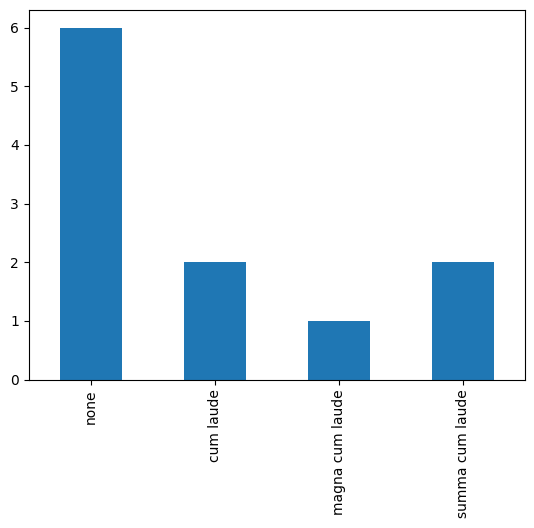

In [43]:
student_results_degree.value_counts().plot.bar()